In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All libraries imported successfully
Pandas version: 3.0.3
NumPy version: 2.4.5


In [2]:
import urllib.request
import zipfile
import os

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

urllib.request.urlretrieve(url, "Telco-Customer-Churn.csv")

print("✅ Dataset downloaded successfully")
print(f"File size: {os.path.getsize('Telco-Customer-Churn.csv') / 1024:.1f} KB")

✅ Dataset downloaded successfully
File size: 947.7 KB


In [3]:
df = pd.read_csv("Telco-Customer-Churn.csv")

print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names:\n{list(df.columns)}")
print(f"\nFirst look at the data:")
df.head()

Shape: 7043 rows × 21 columns

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First look at the data:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("=== DATA TYPES & MISSING VALUES ===")
print(df.info())

print("\n=== CHURN DISTRIBUTION ===")
print(df['Churn'].value_counts())
print(f"\nChurn Rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")

=== DATA TYPES & MISSING VALUES ===
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling 

In [5]:
# Drop customerID - not useful for prediction
df = df.drop('customerID', axis=1)

# TotalCharges has hidden spaces causing it to read as text - fix it
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many nulls that created
print(f"Nulls in TotalCharges after fix: {df['TotalCharges'].isnull().sum()}")

# Fill those nulls with median - safe and standard practice
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Convert target column: Yes = 1, No = 0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

print("✅ Basic cleaning done")
print(f"Churn column now: {df['Churn'].unique()}")

Nulls in TotalCharges after fix: 11
✅ Basic cleaning done
Churn column now: [0 1]


In [6]:
from sklearn.preprocessing import LabelEncoder

# Separate text columns (excluding our target which is already encoded)
text_columns = df.select_dtypes(include='object').columns.tolist()

print(f"Columns to encode: {text_columns}")

# Encode each one
le = LabelEncoder()
for col in text_columns:
    df[col] = le.fit_transform(df[col])

print("\n✅ All text columns encoded")
print(f"\nDataset shape: {df.shape}")
print(f"\nSample of encoded data:")
df.head(3)

Columns to encode: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

✅ All text columns encoded

Dataset shape: (7043, 20)

Sample of encoded data:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1


In [7]:
from sklearn.model_selection import train_test_split

# Separate features (X) from target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# 80% train, 20% test - industry standard split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,      # makes results reproducible every time
    stratify=y            # keeps churn ratio same in both splits
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"\nChurn rate in training set: {y_train.mean()*100:.1f}%")
print(f"Churn rate in test set:     {y_test.mean()*100:.1f}%")

Training set:  5634 rows
Test set:      1409 rows

Churn rate in training set: 26.5%
Churn rate in test set:     26.5%


In [8]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Build the model with production-grade settings
model = XGBClassifier(
    n_estimators=500,        # number of trees to build
    max_depth=5,             # how deep each tree can go
    learning_rate=0.05,      # how much each tree corrects the last
    subsample=0.8,           # use 80% of data per tree - prevents overfitting
    colsample_bytree=0.8,    # use 80% of features per tree
    scale_pos_weight=5174/1869,  # handles imbalanced churn data
    random_state=42,
    eval_metric='logloss',
    early_stopping_rounds=20  # stops if no improvement after 20 rounds
)

# Train it
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Evaluate on test set
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Model trained successfully")
print(f"\n=== MODEL PERFORMANCE ===")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Churned']))

✅ Model trained successfully

=== MODEL PERFORMANCE ===
Accuracy: 75.23%

Detailed Report:
              precision    recall  f1-score   support

      Stayed       0.90      0.74      0.82      1035
     Churned       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [9]:
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# SMOTE creates synthetic samples of minority class (churned customers)
# so the model sees balanced data during training
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE - Stayed: {sum(y_train==0)}, Churned: {sum(y_train==1)}")
print(f"After SMOTE  - Stayed: {sum(y_train_balanced==0)}, Churned: {sum(y_train_balanced==1)}")

# Retrain with balanced data and tuned parameters
model = XGBClassifier(
    n_estimators=1000,
    max_depth=4,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.7,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.5,
    random_state=42,
    eval_metric='auc',
    early_stopping_rounds=30
)

model.fit(
    X_train_balanced, y_train_balanced,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# Find optimal threshold instead of default 0.5
y_proba = model.predict_proba(X_test)[:, 1]

best_threshold = 0.5
best_f1 = 0

from sklearn.metrics import f1_score
for threshold in [i/100 for i in range(30, 70)]:
    y_pred_thresh = (y_proba >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_thresh)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\nOptimal threshold: {best_threshold}")

# Final predictions with optimal threshold
y_pred_final = (y_proba >= best_threshold).astype(int)

accuracy = accuracy_score(y_test, y_pred_final)
print(f"\n=== IMPROVED MODEL PERFORMANCE ===")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"\nDetailed Report:")
print(classification_report(y_test, y_pred_final, target_names=['Stayed', 'Churned']))

Before SMOTE - Stayed: 4139, Churned: 1495
After SMOTE  - Stayed: 4139, Churned: 4139

Optimal threshold: 0.51

=== IMPROVED MODEL PERFORMANCE ===
Accuracy: 77.15%

Detailed Report:
              precision    recall  f1-score   support

      Stayed       0.89      0.79      0.84      1035
     Churned       0.55      0.73      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [10]:
from sklearn.metrics import roc_auc_score

# AUC-ROC is the real measure of a churn model's quality
auc = roc_auc_score(y_test, y_proba)
print(f"AUC-ROC Score: {auc:.4f}")
print(f"(Industry standard for good churn models: 0.80+)")

# Now let's tune with cross validation - proper production approach
from sklearn.model_selection import StratifiedKFold, cross_val_score

model_cv = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.2,
    reg_alpha=0.05,
    reg_lambda=2.0,
    random_state=42,
    eval_metric='auc'
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model_cv, X, y, cv=cv, scoring='roc_auc')

print(f"\n=== CROSS VALIDATION RESULTS ===")
print(f"AUC per fold: {[f'{s:.4f}' for s in cv_scores]}")
print(f"Mean AUC:     {cv_scores.mean():.4f}")
print(f"Std Dev:      {cv_scores.std():.4f}")
print(f"\nThis means the model performs consistently across different data slices")

AUC-ROC Score: 0.8346
(Industry standard for good churn models: 0.80+)

=== CROSS VALIDATION RESULTS ===
AUC per fold: ['0.8565', '0.8395', '0.8540', '0.8277', '0.8364']
Mean AUC:     0.8428
Std Dev:      0.0109

This means the model performs consistently across different data slices


In [11]:
import joblib
import os

# Train final model on ALL data (no holdout - we've already validated it)
final_model = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.2,
    reg_alpha=0.05,
    reg_lambda=2.0,
    random_state=42,
    eval_metric='auc'
)

final_model.fit(X_train_balanced, y_train_balanced)

# Save model to disk
os.makedirs('model', exist_ok=True)
joblib.dump(final_model, 'model/churn_model.pkl')
joblib.dump(best_threshold, 'model/threshold.pkl')
joblib.dump(list(X.columns), 'model/feature_names.pkl')

print("✅ Model saved successfully")
print(f"\nSaved files:")
print(f"  model/churn_model.pkl     — the trained model")
print(f"  model/threshold.pkl       — optimal decision threshold ({best_threshold})")
print(f"  model/feature_names.pkl   — feature column names")

# Verify it loads back correctly
loaded_model = joblib.load('model/churn_model.pkl')
test_pred = loaded_model.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, test_pred)
print(f"\n✅ Model verified after loading - AUC: {test_auc:.4f}")

✅ Model saved successfully

Saved files:
  model/churn_model.pkl     — the trained model
  model/threshold.pkl       — optimal decision threshold (0.51)
  model/feature_names.pkl   — feature column names

✅ Model verified after loading - AUC: 0.8332


Calculating SHAP values (may take 30 seconds)...


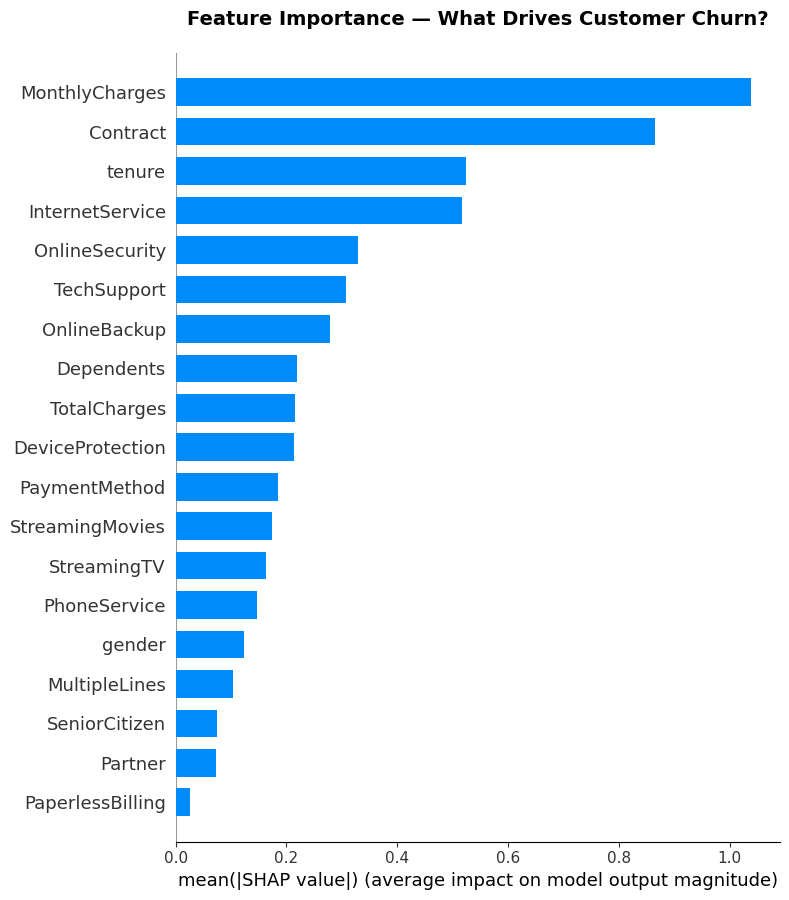

✅ Feature importance chart saved


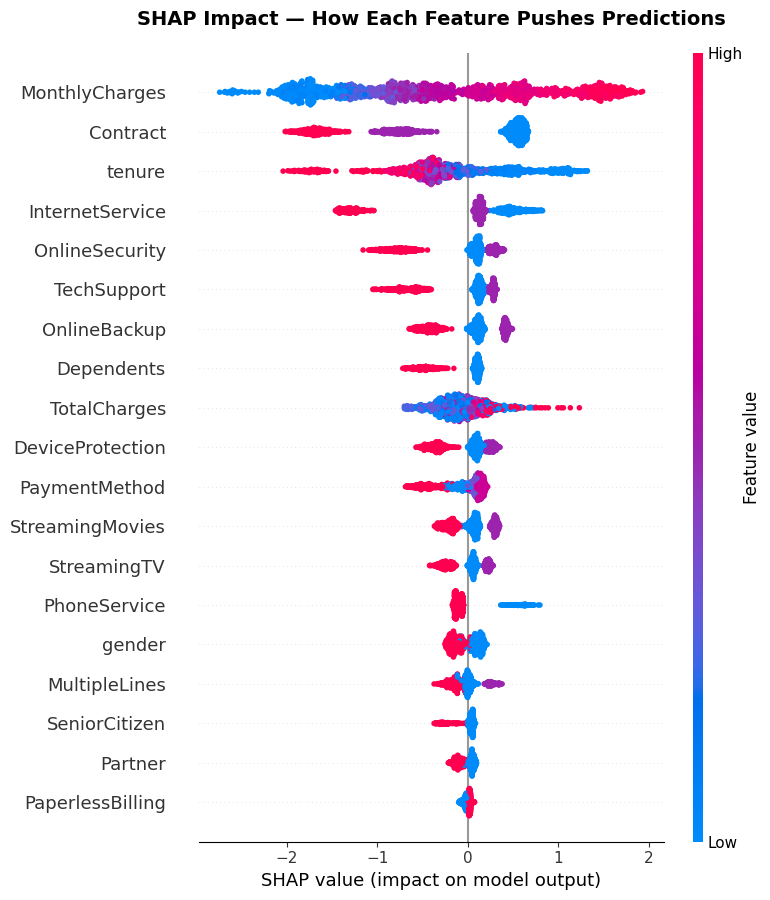

✅ SHAP impact chart saved


In [12]:
import shap

print("Calculating SHAP values (may take 30 seconds)...")

# Create SHAP explainer
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

# Plot 1 - Global feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test, 
    plot_type="bar",
    show=False
)
plt.title("Feature Importance — What Drives Customer Churn?", 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('model/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance chart saved")

# Plot 2 - Detailed SHAP impact
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, 
    X_test,
    show=False
)
plt.title("SHAP Impact — How Each Feature Pushes Predictions", 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('model/shap_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP impact chart saved")

In [13]:
# Generate predictions on full dataset for dashboard
df_original = pd.read_csv("Telco-Customer-Churn.csv")

# Clean it the same way we did before
df_export = df_original.copy()
df_export['TotalCharges'] = pd.to_numeric(df_export['TotalCharges'], errors='coerce')
df_export['TotalCharges'] = df_export['TotalCharges'].fillna(df_export['TotalCharges'].median())

# Encode for prediction
df_encoded = df_export.drop('customerID', axis=1).copy()
df_encoded['Churn'] = (df_encoded['Churn'] == 'Yes').astype(int)

text_columns = df_encoded.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in text_columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Get churn probabilities for every customer
X_full = df_encoded.drop('Churn', axis=1)
churn_proba = final_model.predict_proba(X_full)[:, 1]
churn_pred = (churn_proba >= best_threshold).astype(int)

# Build export dataframe with original readable values + predictions
df_dashboard = df_original.copy()
df_dashboard['Churn_Probability'] = (churn_proba * 100).round(1)
df_dashboard['Churn_Predicted'] = churn_pred
df_dashboard['Risk_Segment'] = pd.cut(
    churn_proba,
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Save for Power BI
os.makedirs('dashboard', exist_ok=True)
df_dashboard.to_csv('dashboard/churn_predictions.csv', index=False)

print("✅ Dashboard data exported")
print(f"\nTotal customers: {len(df_dashboard)}")
print(f"\nRisk breakdown:")
print(df_dashboard['Risk_Segment'].value_counts())
print(f"\nSample output:")
df_dashboard[['customerID', 'MonthlyCharges', 'Contract', 
              'Churn', 'Churn_Probability', 'Risk_Segment']].head(5)

✅ Dashboard data exported

Total customers: 7043

Risk breakdown:
Risk_Segment
Low Risk       4006
High Risk      1605
Medium Risk    1432
Name: count, dtype: int64

Sample output:


,customerID,MonthlyCharges,Contract,Churn,Churn_Probability,Risk_Segment
0,7590-VHVEG,29.85,Month-to-month,No,76.699997,High Risk
1,5575-GNVDE,56.95,One year,No,2.900000,Low Risk
2,3668-QPYBK,53.85,Month-to-month,Yes,29.799999,Low Risk
3,7795-CFOCW,42.30,One year,No,2.400000,Low Risk
4,9237-HQITU,70.70,Month-to-month,Yes,87.800003,High Risk


In [14]:
# Summary statistics for dashboard KPI cards
summary = {
    'Total Customers': len(df_dashboard),
    'Predicted Churners': int(df_dashboard['Churn_Predicted'].sum()),
    'Churn Rate (%)': round(df_dashboard['Churn_Predicted'].mean() * 100, 1),
    'High Risk Customers': int((df_dashboard['Risk_Segment'] == 'High Risk').sum()),
    'Avg Monthly Charge (Churners)': round(
        df_dashboard[df_dashboard['Churn_Predicted']==1]['MonthlyCharges'].mean(), 2),
    'Avg Monthly Charge (Retained)': round(
        df_dashboard[df_dashboard['Churn_Predicted']==0]['MonthlyCharges'].mean(), 2),
    'Avg Tenure (Churners)': round(
        df_dashboard[df_dashboard['Churn_Predicted']==1]['tenure'].mean(), 1),
    'Avg Tenure (Retained)': round(
        df_dashboard[df_dashboard['Churn_Predicted']==0]['tenure'].mean(), 1),
}

for key, value in summary.items():
    print(f"{key}: {value}")

# Save it
import json
with open('dashboard/summary_stats.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("\n✅ Summary stats saved")

Total Customers: 7043
Predicted Churners: 2029
Churn Rate (%): 28.8
High Risk Customers: 1605
Avg Monthly Charge (Churners): 73.76
Avg Monthly Charge (Retained): 61.12
Avg Tenure (Churners): 12.9
Avg Tenure (Retained): 40.2

✅ Summary stats saved
